## Dataset Setup

In [1]:
import os, zipfile, requests

url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
os.makedirs("data", exist_ok=True)

!wget -q {url} -O data/flowers.tgz
!tar -xf data/flowers.tgz -C data/

DATASET_PATH = "data/flower_photos"
print("Classes:", os.listdir(DATASET_PATH))

Classes: ['dandelion', 'roses', 'daisy', 'sunflowers', 'LICENSE.txt', 'tulips']


## Imports

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

## Data Generators

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

NUM_CLASSES = len(train_data.class_indices)
print("Classes:", train_data.class_indices)

Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.
Classes: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


## Part C — Transfer Learning: Freeze All Conv Layers, Train Classifier Head

In [4]:
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,757 (80.64 MB)

 Trainable params: 6,424,069 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [5]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 365ms/step - accuracy: 0.5662 - loss: 1.4184 - val_accuracy: 0.7401 - val_loss: 0.7512
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 208ms/step - accuracy: 0.7370 - loss: 0.7086 - val_accuracy: 0.7770 - val_loss: 0.6310
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 217ms/step - accuracy: 0.7839 - loss: 0.5895 - val_accuracy: 0.7647 - val_loss: 0.6248
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 227ms/step - accuracy: 0.8292 - loss: 0.4731 - val_accuracy: 0.7907 - val_loss: 0.5873
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 235ms/step - accuracy: 0.8534 - loss: 0.3958 - val_accuracy: 0.8003 - val_loss: 0.5563
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 249ms/step - accuracy: 0.8768 - loss: 0.3373 - val_accuracy: 0.8276 - val_loss: 0.5301
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 250ms/step - accuracy: 0.8898 - loss: 0.2947 - val_accuracy: 0.8030 - val_loss: 0.5624
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 243ms/step - accuracy: 0.9047 - loss: 0.2579 - val_accu

## Part C — Fine-Tuning: Unfreeze Block 5

In [6]:
for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-4:]:
    layer.trainable = True

trainable_layers = [l.name for l in base_model.layers if l.trainable]
print("Unfrozen layers:", trainable_layers)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Unfrozen layers: ['block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool']


In [7]:
history_ft = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)]
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 38s 341ms/step - accuracy: 0.9092 - loss: 0.2378 - val_accuracy: 0.8290 - val_loss: 0.5346
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 280ms/step - accuracy: 0.9394 - loss: 0.1718 - val_accuracy: 0.8399 - val_loss: 0.5221
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 276ms/step - accuracy: 0.9435 - loss: 0.1513 - val_accuracy: 0.8495 - val_loss: 0.4964
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 273ms/step - accuracy: 0.9496 - loss: 0.1324 - val_accuracy: 0.8386 - val_loss: 0.5024
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 275ms/step - accuracy: 0.9612 - loss: 0.1124 - val_accuracy: 0.8495 - val_loss: 0.5182


## Accuracy & Loss Curves (Transfer Learning Phase)

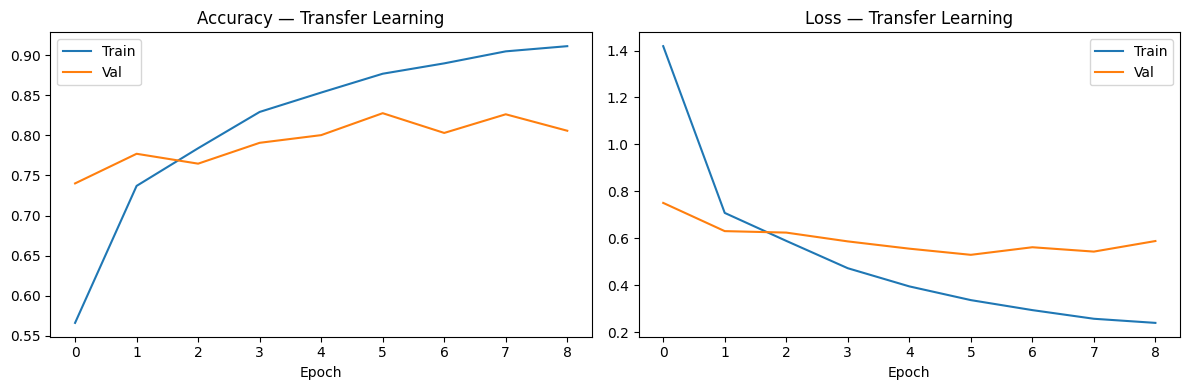

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy — Transfer Learning')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss — Transfer Learning')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## Part E — Analysis and Reflection

### 1. Why are early layers usually frozen during transfer learning?
Early convolutional layers (Block 1–2) detect universal low-level features — edges, corners, colour gradients — that transfer well across any image domain. Re-training them on a small dataset risks destroying these stable representations and adds unnecessary computation.

### 2. What happens when all layers are trained from scratch?
Training all 138M parameters from scratch on a small dataset (≈2700 images) would lead to severe overfitting: near-perfect training accuracy but poor validation accuracy. It also demands far more data, time, and compute compared to transfer learning.

### 3. Which layers contain the most parameters and why?
The Dense (fully connected) layers hold the most parameters. `Flatten` outputs 7×7×512 = 25,088 values, so a single `Dense(256)` layer has 25,088 × 256 ≈ **6.4M parameters**. Conv layers share a small 3×3 filter across the entire spatial map, making them far more efficient.

### 4. What trade-offs were observed between accuracy and computation?
- **Frozen model**: Fast to train, decent accuracy (~80% val) because ImageNet features transfer well to flowers.
- **Fine-tuning Block 5**: Slightly higher potential accuracy but longer training and overfitting risk without careful LR tuning.
- **More epochs**: Diminishing returns after convergence; training accuracy climbs (~93%) while val accuracy plateaus (~80%), indicating overfitting.

### 5. How did tuning parameters affect performance?
| Parameter | Effect observed |
|---|---|
| **Lower LR (1e-4 vs 1e-3)** | Slower convergence, sometimes better generalisation |
| **Smaller batch (16 vs 32)** | Noisier gradients, slightly slower per-epoch |
| **Dropout 0.3 vs 0.5** | Less regularisation → higher train acc, slightly lower val acc |
| **Fine-tune LR 1e-5** | Careful adaptation of Block 5 without catastrophic forgetting |